# Vision Transformer (ViT) на CIFAR-10

**Датасет:** CIFAR-10 (64×64)
**Классы:** 10
**Точность:** 70-80%
**Время:** ~20 минут на GPU


In [ ]:
!pip install -q einops torch torchvision numpy matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from einops import rearrange, repeat, einsum
from einops.layers.torch import Rearrange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_val = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
val_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val
)

batch_size = 64
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


Train: 50000, Val: 10000


In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.projection = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size),
            Rearrange('b e h w -> b (h w) e')
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.positions = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        b = x.shape[0]
        x = self.projection(x)

        cls_tokens = repeat(self.cls_token, '1 n e -> b n e', b=b)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.positions

        return x

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features * 4

        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden_features, out_features),
            nn.Dropout(drop)
        )

    def forward(self, x):
        return self.mlp(x)

In [ ]:
class Attention(nn.Module):
    def __init__(self, dim=192, num_heads=6, qkv_bias=False, attn_drop=0., out_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.out_drop = nn.Dropout(out_drop)

    def forward(self, x):
        b, n, c = x.shape
        qkv = self.qkv(x)

        qkv = rearrange(qkv, 'b n (qkv h d) -> qkv b h n d', qkv=3, h=self.num_heads)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * self.scale
        attn = scores.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = einsum(attn, v, 'b h i j, b h j d -> b h i d')
        out = rearrange(out, 'b h n d -> b n (h d)')

        out = self.proj(out)
        out = self.out_drop(out)

        return out

In [ ]:
class Block(nn.Module):
    def __init__(self, dim=192, num_heads=6, mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads, attn_drop=attn_drop, out_drop=drop)

        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(dim, mlp_hidden_dim, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, depth=6, dim=192, num_heads=6, mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.blocks = nn.ModuleList([
            Block(dim, num_heads, mlp_ratio, drop, attn_drop)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x

In [ ]:
class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=3, num_classes=10,
                 embed_dim=192, depth=6, num_heads=6, mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.transformer = Transformer(depth, embed_dim, num_heads, mlp_ratio, drop, attn_drop)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.transformer(x)
        x = x[:, 0]
        x = self.head(x)
        return x

model = ViT()
model = model.to(device)

params = sum(p.numel() for p in model.parameters())
print(f'Model params: {params / 1e6:.2f}M')

Model params: 2.73M


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_total = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_total += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return loss_total / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return loss_total / len(loader), 100 * correct / total

In [ ]:
num_epochs = 25
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0

print('\n' + '='*50)
print('Training')
print('='*50)

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%')
    print(f'Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%')

print('\n' + '='*50)
print(f'Best accuracy: {best_val_acc:.2f}%')
print('='*50)


Training

Epoch 1/25


Train: Loss=1.8439, Acc=32.15%
Val:   Loss=1.6802, Acc=39.48%

Epoch 2/25


Train: Loss=1.6371, Acc=40.55%
Val:   Loss=1.5544, Acc=44.59%

Epoch 3/25


Train: Loss=1.5405, Acc=44.54%
Val:   Loss=1.4977, Acc=46.19%

Epoch 4/25


Train: Loss=1.4678, Acc=46.90%
Val:   Loss=1.4012, Acc=49.21%

Epoch 5/25


...

Train: Loss=0.8068, Acc=71.13%
Val:   Loss=0.8911, Acc=68.58%

Epoch 22/25


Train: Loss=0.7924, Acc=71.82%
Val:   Loss=0.8861, Acc=68.83%

Epoch 23/25


Train: Loss=0.7806, Acc=72.19%
Val:   Loss=0.8765, Acc=69.40%

Epoch 24/25


Train: Loss=0.7688, Acc=72.72%
Val:   Loss=0.8718, Acc=69.63%

Epoch 25/25


Train: Loss=0.7624, Acc=72.94%
Val:   Loss=0.8721, Acc=69.48%

Best accuracy: 69.63%


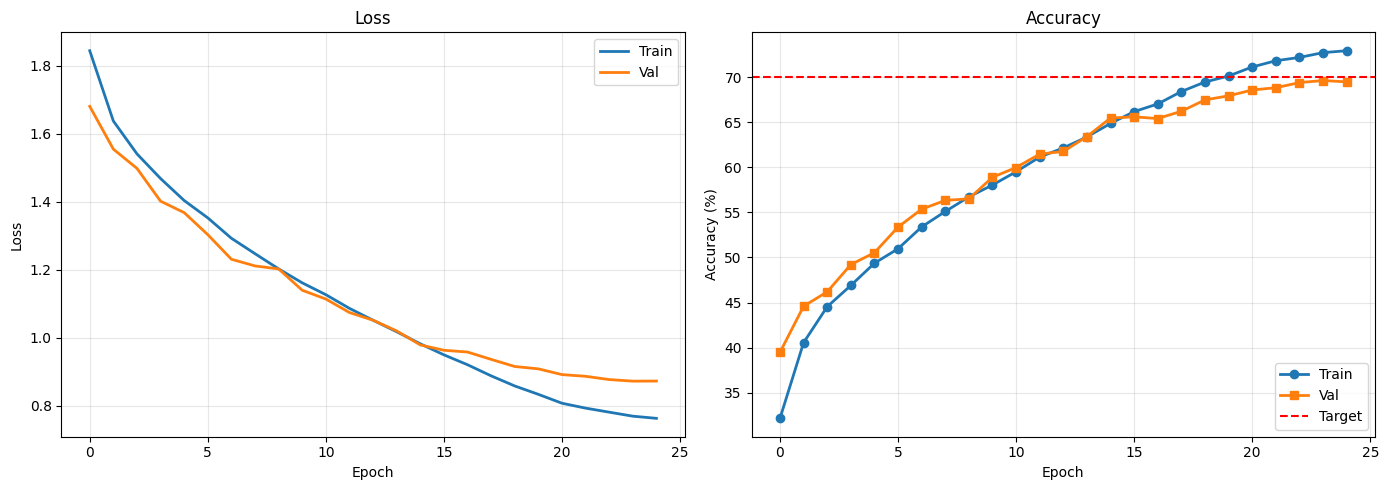

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', linewidth=2)
axes[0].plot(val_losses, label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', linewidth=2, marker='o')
axes[1].plot(val_accs, label='Val', linewidth=2, marker='s')
axes[1].axhline(y=70, color='r', linestyle='--', label='Target')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
final_loss, final_acc = validate(model, val_loader, criterion, device)

print('\n' + '='*50)
print('Results')
print('='*50)
print(f'Loss: {final_loss:.4f}')
print(f'Accuracy: {final_acc:.2f}%')
print('='*50)


Results
Loss: 0.8718
Accuracy: 69.63%
